# Correlation Analysis

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
from life_expectancy.data.utils import resolve_project_path
from life_expectancy.data.preprocessing import  build_processed_dataset

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)

panel, summary = build_processed_dataset(config)

panel.head()

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed


,country,year,status,life_expectancy_who,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,co2,health_expenditure_percent,education_expenditure_percent,unemployment,corruption,sanitation,injuries,communicable,noncommunicable_disease,life_expectancy
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,100,...,5949.999809,10.105348,3.25580,11.127,2.0,NaN,3673696.62,6528888.62,6988545.28,64.1885
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,100,...,4880.000114,9.528871,3.69522,11.142,2.0,NaN,3267937.78,6649335.87,6900348.40,61.4330
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,100,...,5989.999771,8.805941,3.45446,11.193,2.0,NaN,2807904.86,6813189.19,6799914.37,61.2125
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,100,...,8079.999924,7.897176,3.32000,11.341,2.0,NaN,2715550.23,7036448.02,6640268.93,60.7770
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,100,...,8930.000305,8.561907,3.46201,11.054,2.0,NaN,2540038.63,7181018.86,6539124.12,60.3765


In [16]:
from life_expectancy.features.feature_engineering import prepare_numeric_model_frame

model_df = prepare_numeric_model_frame(panel, config)

numeric_cols = [
    col for col in model_df.columns
]

model_df[numeric_cols].describe()

,year,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,...,gdp_log1p,population_log1p,co2_log1p,gdp_missing_flag,schooling_missing_flag,sanitation_missing_flag,adult_mortality_missing_flag,schooling__x__status_flag,gdp_log1p__x__status_flag,life_expectancy
count,2265.000000,2265.000000,2265.000000,2104.000000,2265.000000,1860.000000,2265.000000,2235.000000,2265.000000,2250.000000,...,2245.000000,2051.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.0,2250.000000,2245.000000,2265.000000
mean,2008.000000,162.533333,31.773068,4.602101,902.315351,80.868817,41.938631,38.574362,44.173510,82.495111,...,7.503948,13.913630,9.337161,0.008830,0.006623,0.352318,0.0,2.978311,1.729823,69.243516
std,4.321448,125.275671,125.744102,4.037729,2202.171853,24.793564,45.397082,20.076763,170.331501,23.345135,...,1.875694,2.652445,2.319876,0.093573,0.081127,0.477798,0.0,6.263617,3.666478,9.575684
min,2001.000000,1.000000,0.000000,0.010000,0.000000,2.000000,0.000000,1.800000,0.000000,3.000000,...,0.986320,3.555348,3.931826,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,40.684500
25%,2004.000000,69.000000,0.000000,0.827500,23.727963,76.000000,0.000000,19.300000,0.000000,77.000000,...,6.178540,12.272537,7.687539,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,62.840000
50%,2008.000000,139.000000,3.000000,3.910000,121.362547,92.000000,14.000000,44.300000,3.000000,93.000000,...,7.521095,14.174427,9.340579,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,72.091500
75%,2012.000000,227.000000,21.000000,7.600000,584.099343,96.000000,100.000000,56.500000,28.000000,97.000000,...,8.745801,15.827526,10.984292,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,75.846000
max,2015.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,100.000000,77.600000,2400.000000,99.000000,...,11.688338,20.980895,15.409517,1.000000,1.000000,1.000000,0.0,20.700000,11.688338,85.143902


## Correlation with Life Expectancy

In [19]:
target_col = config["features"]["target_col"]

corr_with_target = (
    model_df.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)
corr_with_target

schooling                          0.770792
income_composition_of_resources    0.760478
sanitation                         0.698150
gdp_log1p                          0.611052
bmi                                0.587977
diphtheria                         0.509590
schooling__x__status_flag          0.497621
gdp_log1p__x__status_flag          0.495222
status_flag                        0.494184
co2_log1p                          0.492597
polio                              0.481025
gdp                                0.465090
alcohol                            0.414382
percentage_expenditure             0.409100
health_expenditure_percent         0.318260
education_expenditure_percent      0.297143
hepatitis_b                        0.264873
corruption                         0.209583
total_expenditure                  0.198253
year                               0.162685
co2                                0.141714
noncommunicable_disease            0.028875
injuries                        

### Top correlations

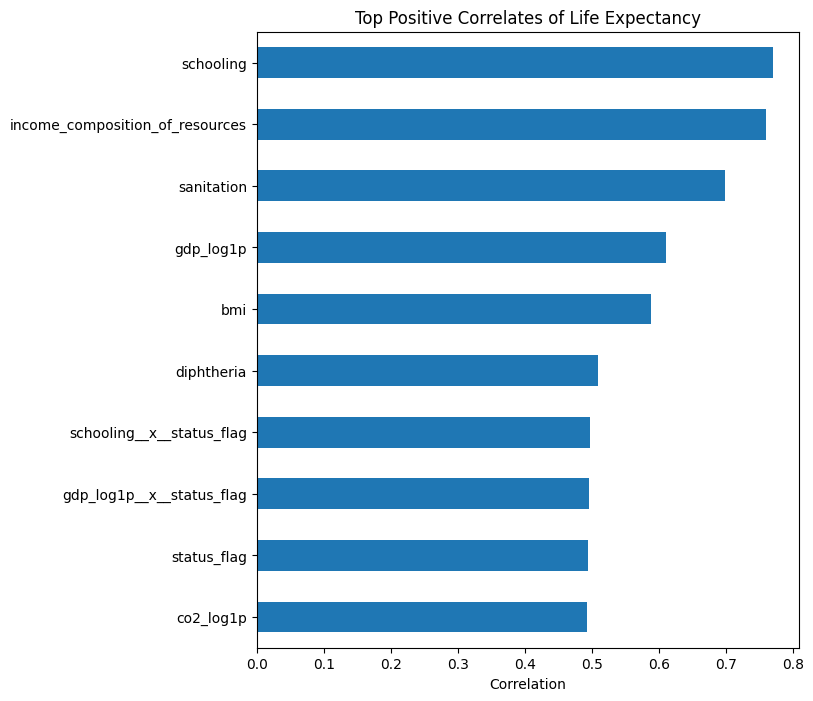

In [20]:
plt.figure(figsize=(7,8))
corr_with_target.head(10).plot(kind="barh")
plt.title("Top Positive Correlates of Life Expectancy")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.show()

### Bottom Correlations

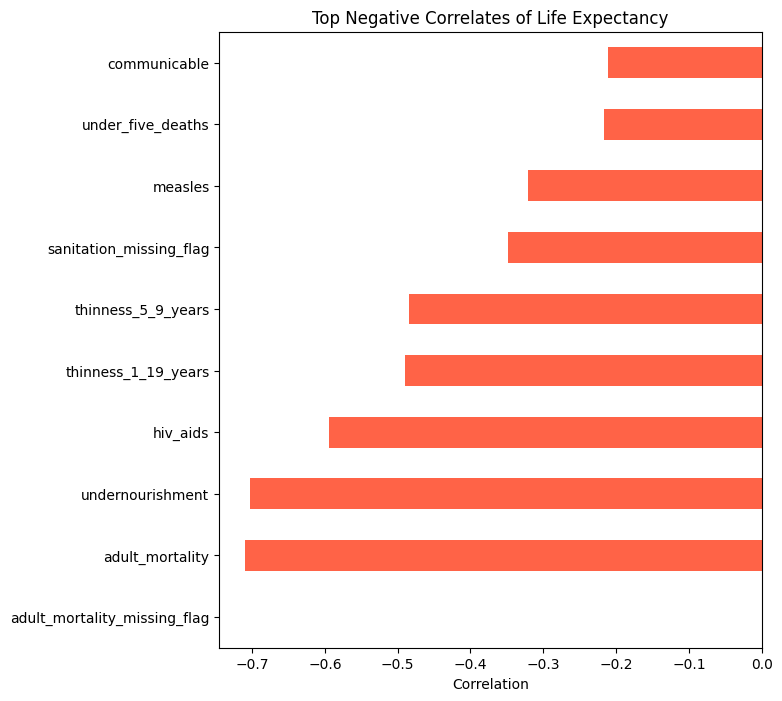

In [21]:
plt.figure(figsize=(7,8))
corr_with_target.tail(10).plot(kind="barh", color="tomato")
plt.title("Top Negative Correlates of Life Expectancy")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.show()


Correlation analysis reveals clear relationships between socioeconomic and health indicators and life expectancy. Education (schooling), income composition, sanitation access, and health expenditure show strong positive associations with life expectancy. Conversely, mortality-related indicators such as adult mortality, HIV/AIDS prevalence, and communicable disease burden exhibit strong negative correlations. These results align with established public health theory and confirm that the dataset captures meaningful real-world health determinants.

## Full Correlation Heatmap

In [22]:
key_vars = [
    "life_expectancy",
    "schooling",
    "income_composition_of_resources",
    "gdp",
    "health_expenditure_percent",
    "sanitation",
    "adult_mortality",
    "hiv_aids",
    "under_five_deaths",
    "communicable",
    "noncommunicable_disease",
    "undernourishment",
    "measles",
    "bmi",
    "polio"
]

corr_matrix = panel[key_vars].corr()

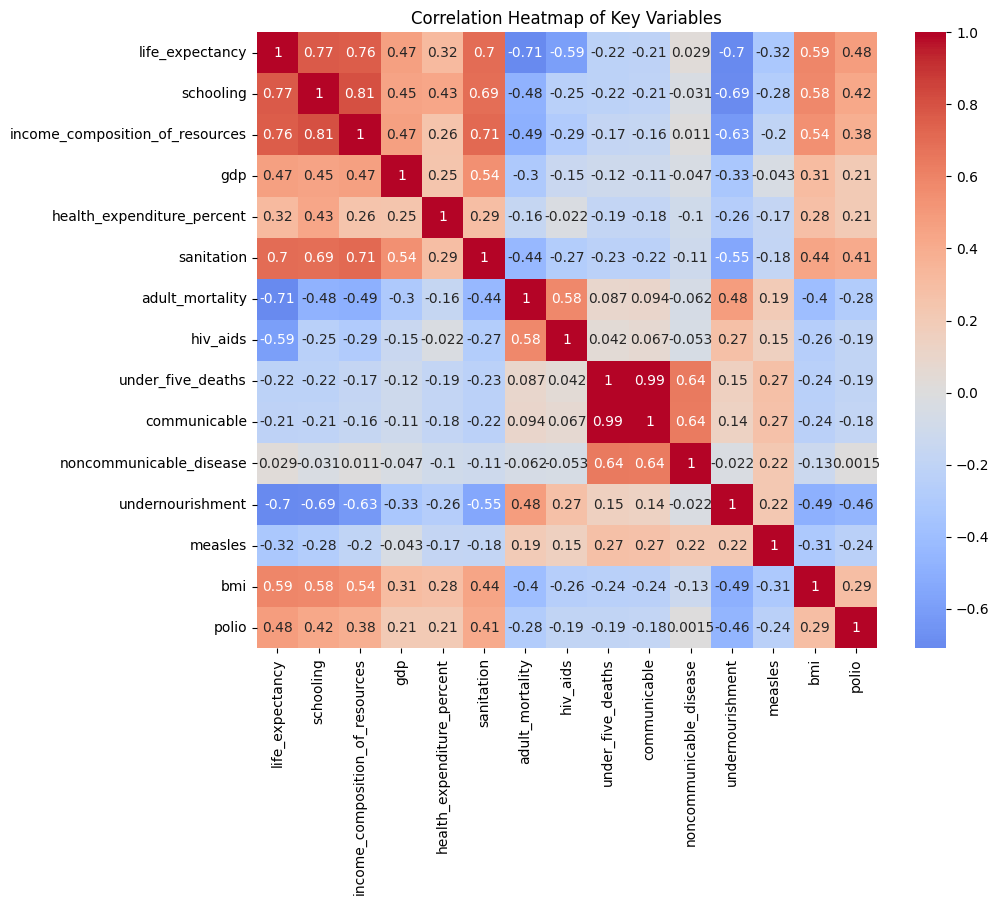

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Variables")
plt.show()

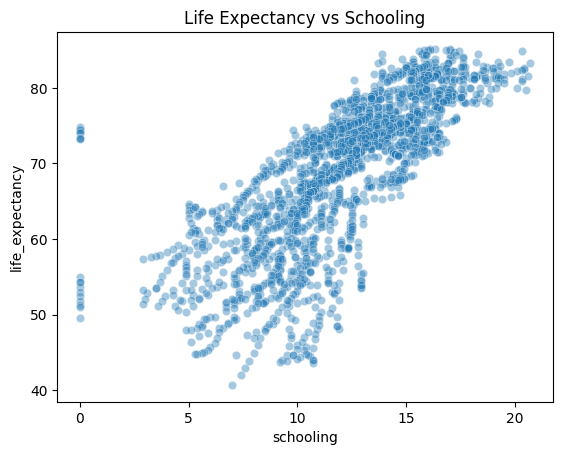

In [24]:
sns.scatterplot(data=panel, x="schooling", y="life_expectancy", alpha=0.4)
plt.title("Life Expectancy vs Schooling")
plt.show()

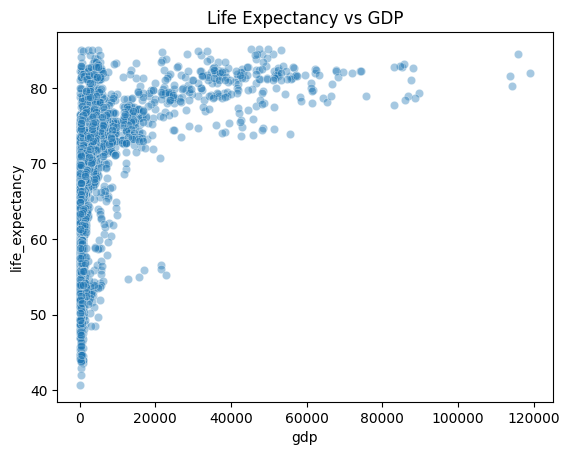

In [25]:
sns.scatterplot(data=panel, x="gdp", y="life_expectancy", alpha=0.4)
plt.title("Life Expectancy vs GDP")
plt.show()

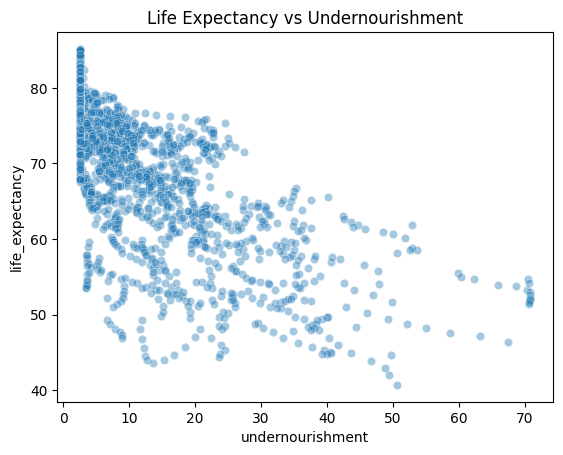

In [26]:
sns.scatterplot(data=panel, x="undernourishment", y="life_expectancy", alpha=0.4)
plt.title("Life Expectancy vs Undernourishment")
plt.show()


Scatterplot analysis confirms the relationships observed in the correlation coefficients. Life expectancy increases with schooling and economic development, while higher undernourishment rates are associated with sharply lower life expectancy. The relationships appear approximately monotonic, supporting the use of regression modeling in the next stage of analysis.

## Multicollinearity Check

In [27]:
from life_expectancy.features.feature_selection import high_correlation_pairs

high_corr_pairs = high_correlation_pairs(
    model_df,
    threshold=0.85,
)

high_corr_pairs


,feature_1,feature_2,correlation,abs_correlation
0,under_five_deaths,infant_deaths,0.996563,0.996563
1,communicable,under_five_deaths,0.993354,0.993354
2,schooling__x__status_flag,status_flag,0.992756,0.992756
3,communicable,infant_deaths,0.991963,0.991963
4,gdp_log1p__x__status_flag,status_flag,0.983685,0.983685
5,gdp_log1p__x__status_flag,schooling__x__status_flag,0.979858,0.979858
6,noncommunicable_disease,injuries,0.958412,0.958412
7,thinness_5_9_years,thinness_1_19_years,0.933035,0.933035
8,noncommunicable_disease,co2,0.904517,0.904517
9,gdp,percentage_expenditure,0.900629,0.900629


A multicollinearity check was performed using pairwise correlation coefficients among all numeric variables. Several predictors exhibit extremely high correlations (|r| > 0.85), indicating redundancy in the dataset. In particular, infant deaths and under-five deaths are almost perfectly correlated (r ≈ 0.997), and both are also strongly related to communicable disease burden, suggesting they measure similar underlying child mortality conditions. The two nutritional indicators (thinness 1–19 years and thinness 5–9 years) also capture essentially the same information (r ≈ 0.93). Economic variables show overlap as well, with GDP highly correlated with percentage health expenditure. Additionally, the WHO and World Bank life expectancy measures are nearly identical (r ≈ 0.98), and both are almost perfectly correlated with the constructed life_expectancy variable, as expected since it is derived from them. Finally, several health burden indicators (communicable disease, injuries, and non-communicable disease) are strongly interrelated, reflecting shared underlying development and healthcare capacity factors. These findings imply that many predictors cannot be included simultaneously in a regression model without causing instability in coefficient estimates, and therefore feature selection or dimensionality reduction will be necessary in the modeling stage.